# Notebook 10 — Où le modèle fonctionne-t-il ? Analyse par segment de taille

**Objectif de ce notebook :** répondre à une question que le notebook 08 ne pose pas —
« mon modèle prédit-il aussi bien les **petites** que les **grandes** capitalisations ? »

Les **mêmes** prédictions que celles du notebook 08 (`outputs/predictions_*.parquet`) sont
simplement **ré-évaluées séparément** sur chaque segment de capitalisation boursière.

⚠️ **Aucun ré-entraînement, aucune modification des étapes 04 à 07.** Les 4 modèles restent
entraînés *et* évalués sur l'univers **complet**, exactement comme avant : ce notebook ne
change rien à leurs résultats, à leurs prédictions, ni à leurs entrées au journal des
expériences.Un modèle unique entraîné sur tout l'univers, dont on regarde ensuite la performance sous-univers par sous-univers.


**Plan :**
1. Le découpage retenu et la **taille réelle, en dollars**, des entreprises de chaque groupe
2. Comment ces capitalisations évoluent sur la période
3. `R²_oos` par modèle et par groupe
4. **Rank-IC** par modèle et par groupe ← *la mesure à privilégier pour comparer les groupes*
5. Rendement moyen par décile, groupe par groupe
6. Portefeuilles long-short construits **à l'intérieur de chaque groupe**
7. Richesse cumulée et synthèse

⚠️ **Pré-requis** : avoir lancé `python scripts/etape10_analyse_par_taille.py`, lui-même
précédé de `python scripts/etape03_construction_panel.py` (qui écrit les colonnes
`mvel1_brut` et `groupe_taille` dans le panel) et d'au moins un des scripts 04 à 07.

---
## ⚠️ Trois avertissements à ne pas oublier dans le mémoire

Ces trois points doivent apparaître **explicitement** dans la rédaction : ce sont les
premières objections qu'un jury formulera sur cette analyse.

### 1. Ces « small caps » n'en sont pas vraiment

L'univers a **déjà** été filtré à l'étape 03 (`config.SEUIL_PERCENTILE_TAILLE` et
`config.SEUIL_PERCENTILE_LIQUIDITE`) : chaque mois, le décile inférieur de capitalisation et
le décile le plus illiquide sont retirés **avant** toute modélisation. Le groupe « Small »
n'est donc **pas** l'univers des micro-capitalisations : c'est la moitié basse d'un univers
déjà expurgé de ses titres les plus petits et les moins liquides.

Formulation correcte dans le mémoire : *« au sein de l'univers investissable retenu (titres
au-dessus du 10ᵉ centile de capitalisation et en dessous du 90ᵉ centile d'illiquidité
d'Amihud, mensuellement), les titres de la moitié inférieure de capitalisation… »* — et non
*« les small caps »* tout court. Les valeurs exactes des deux seuils sont rappelées en
section 1.

### 2. Le `R²_oos` n'est **pas** comparable d'un groupe à l'autre

Le `R²_oos` du projet (voir `fenetres.r2_oos`) compare l'erreur du modèle à une prédiction
naïve de zéro :

$$R^2_{oos} = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i y_i^2}$$

Son **dénominateur** est la somme des rendements réalisés au carré, c'est-à-dire directement
la **variance des rendements du sous-univers considéré**. Les petites capitalisations étant
nettement plus volatiles, leur $\sum y_i^2$ est bien plus grand : leur `R²_oos` est donc tiré
mécaniquement dans une direction qui n'a **rien à voir** avec la qualité de la prédiction.

Comparer directement `R²_oos(Small)` et `R²_oos(Large)` est donc une **erreur de lecture**.
Pour comparer deux groupes, il faut une mesure invariante à l'échelle des rendements :
le **rank-IC** (section 4), qui ne dépend que de l'**ordre** des titres, et le **spread de
décile** / le **Sharpe** du portefeuille long-short (sections 5 et 6), qui traduisent la
valeur économique. Le `R²_oos` reste affiché en section 3, mais uniquement pour comparer les
**modèles entre eux à l'intérieur d'un même groupe** — jamais un groupe à un autre.

### 3. Le découpage est **recalculé à chaque mois**, jamais figé par entreprise

Le groupe d'un titre est réattribué **chaque mois**. En mode relatif (`mediane`, `terciles`,
`quintiles`, `personnalise`), les percentiles sont recalculés sur la population du mois ; en
mode `dollars`, les seuils sont fixes mais la capitalisation du titre, elle, évolue. Dans les
deux cas, une entreprise peut passer de « Small » à « Large » en grandissant, et inversement.

⚠️ **Spécifique au mode `dollars`** : un seuil fixe sur plusieurs décennies ne désigne pas les
mêmes entreprises au début et à la fin de l'échantillon. Le groupe « Large » sera quasi vide
dans les premières années et absorbera une part croissante de l'univers ensuite. La
comparaison Small/Large mélange alors un **effet de taille** et un **effet de période**, ce
qui doit être dit explicitement. Les modes relatifs n'ont pas ce défaut : à chaque date, les
groupes existent et sont de taille comparable.

C'est indispensable : classer une entreprise selon sa taille *moyenne* ou *finale* sur toute
la période utiliserait une **information du futur** (on saurait dès 1990 qu'elle deviendra une
grande capitalisation), exactement le type de fuite que tout le protocole de fenêtres
glissantes cherche à éviter. La contrepartie à mentionner : les groupes ne sont **pas** des
portefeuilles d'entreprises fixes, et le nombre d'entreprises distinctes vues dans chaque
groupe sur l'ensemble de la période (section 1) est bien supérieur à l'effectif d'un mois
donné.

---
## 0. Import des bibliothèques et chargement du rapport

In [1]:
import sys
sys.path.append("..")  # pour importer config.py, portefeuilles.py, rapports.py (a la racine)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config
import rapports

config.assurer_dossiers()

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

# Tout le calcul a deja ete fait par scripts/etape10_analyse_par_taille.py : ce notebook
# ne fait que LIRE et AFFICHER (meme principe que les notebooks 02 a 09).
rap = rapports.charger('10_taille')
print(rap.resume())

NOMS_GROUPES = rap.valeur('noms_groupes')                    # du plus PETIT au plus GRAND
GROUPE_TOUS = rap.valeur('nom_groupe_univers_complet')
ORDRE_GROUPES = [GROUPE_TOUS] + NOMS_GROUPES                 # ordre d'affichage partout
MODELES = rap.valeur('modeles_evalues')
TYPE_SEUILS = rap.valeur('type_seuils')                      # 'percentile' ou 'dollars'

print(f"\nGroupes         : {NOMS_GROUPES}  (+ '{GROUPE_TOUS}' en reference)")
print(f"Modeles evalues : {MODELES}")
print(f"Periode         : {rap.valeur('periode')[0]} a {rap.valeur('periode')[1]} "
      f"({rap.valeur('n_mois')} mois, {rap.valeur('n_entreprises')} entreprises distinctes)")
if rap.valeur('modeles_absents'):
    print(f"\n⚠️ Modeles absents (predictions non trouvees) : {rap.valeur('modeles_absents')}")
if rap.valeur('n_titres_mois_zone_tampon'):
    print(f"\n⚠️ Zone tampon : {rap.valeur('n_titres_mois_zone_tampon')} titres-mois "
          f"({rap.valeur('pct_titres_mois_zone_tampon'):.1f}%) exclus de l'analyse par groupe "
          "(un nom vaut None dans config.NOMS_GROUPES_TAILLE_DOLLARS).")

Rapport '10_taille' produit le 2026-08-16T18:56:44

Groupes         : ['Small', 'Mid', 'Large']  (+ 'Univers complet' en reference)
Modeles evalues : ['Elastic Net', 'LightGBM', 'Random Forest', 'Regression lineaire']
Periode         : 201001 a 202112 (144 mois, 10080 entreprises distinctes)


---
## 1. Le découpage retenu, et la taille réelle des entreprises de chaque groupe

C'est la section à citer dans le mémoire : elle donne, **en dollars**, la capitalisation des
entreprises de chaque groupe, et leur nombre.

In [2]:
print(f"Mode de decoupage (config.MODE_GROUPES_TAILLE) : {rap.valeur('mode_groupes_taille')}")
if TYPE_SEUILS == 'percentile':
    print("Type de coupures : PERCENTILES, recalcules CHAQUE MOIS -> "
          + ", ".join(f"{s:.1%}" for s in rap.valeur('seuils')))
else:
    print("Type de coupures : SEUILS EN DOLLARS, FIXES sur toute la periode -> "
          + ", ".join(f"{s:,.0f} $".replace(',', ' ') for s in rap.valeur('seuils')))
    print("⚠️ Un seuil fixe ne designe pas les memes entreprises en 1980 et en 2020 "
          "(inflation, croissance des marches) :")
    print("   les effectifs mensuels de la section 2 montrent la derive -- regarde-les "
          "avant de conclure.")
print(f"Tranches, de la plus PETITE a la plus GRANDE : {rap.valeur('noms_groupes_avec_zone_tampon')}")
print(f"Groupes reellement analyses                  : {NOMS_GROUPES}")
print()
print("Rappel des filtres deja appliques a l'univers a l'etape 03 (avertissement 1) :")
print(f"  - titres SOUS le {rap.valeur('seuil_percentile_taille_univers'):.0%} de capitalisation : EXCLUS chaque mois")
print(f"  - titres AU-DESSUS du {rap.valeur('seuil_percentile_liquidite_univers'):.0%} d'illiquidite d'Amihud : EXCLUS chaque mois")
print()
print(f"Multiplicateur mvel1 -> dollars : x{rap.valeur('multiplicateur_mvel1_en_dollars'):,.0f} "
      "(config.MULTIPLICATEUR_MVEL1_EN_DOLLARS)")
if TYPE_SEUILS == 'dollars':
    print("⚠️ En mode 'dollars', ce multiplicateur determine A QUOI correspondent tes seuils :")
    print("   verifie-le en section 1bis AVANT d'interpreter les groupes.")

Mode de decoupage (config.MODE_GROUPES_TAILLE) : terciles
Type de coupures : PERCENTILES, recalcules CHAQUE MOIS -> 33.3%, 66.7%
Tranches, de la plus PETITE a la plus GRANDE : ['Small', 'Mid', 'Large']
Groupes reellement analyses                  : ['Small', 'Mid', 'Large']

Rappel des filtres deja appliques a l'univers a l'etape 03 (avertissement 1) :
  - titres SOUS le 10% de capitalisation : EXCLUS chaque mois
  - titres AU-DESSUS du 90% d'illiquidite d'Amihud : EXCLUS chaque mois

Multiplicateur mvel1 -> dollars : x1,000 (config.MULTIPLICATEUR_MVEL1_EN_DOLLARS)


In [3]:
def format_dollars(x):
    # Ecrit une capitalisation en dollars sous une forme lisible (k$, M$, Md$).
    if pd.isna(x):
        return "-"
    for seuil, suffixe in [(1e9, ' Md$'), (1e6, ' M$'), (1e3, ' k$')]:
        if abs(x) >= seuil:
            return f"{x / seuil:,.2f}".replace(',', ' ') + suffixe
    return f"{x:,.0f} $".replace(',', ' ')


descriptif = rap.table('descriptif_groupes').reindex(ORDRE_GROUPES)

colonnes_capi = ['capi_min', 'capi_p25', 'capi_mediane', 'capi_moyenne', 'capi_p75', 'capi_max']
affichage = descriptif.copy()
for c in colonnes_capi:
    affichage[c] = affichage[c].apply(format_dollars)
affichage['n_entreprises_moyen_par_mois'] = affichage['n_entreprises_moyen_par_mois'].round(0).astype(int)
affichage['part_capitalisation_totale_pct'] = affichage['part_capitalisation_totale_pct'].round(1)

print("Capitalisation boursiere et effectifs, par groupe (sur toute la periode de test) :")
affichage[['n_titres_mois', 'n_entreprises_distinctes', 'n_entreprises_moyen_par_mois',
           'part_capitalisation_totale_pct'] + colonnes_capi]

Capitalisation boursiere et effectifs, par groupe (sur toute la periode de test) :


,n_titres_mois,n_entreprises_distinctes,n_entreprises_moyen_par_mois,part_capitalisation_totale_pct,capi_min,capi_p25,capi_mediane,capi_moyenne,capi_p75,capi_max
groupe,,,,,,,,,,
Univers complet,669550,10080,4650,100.0,21.58 M$,265.97 M$,814.44 M$,6.24 Md$,3.08 Md$,2 711.98 Md$
Small,223240,6471,1550,1.0,21.58 M$,109.84 M$,180.12 M$,195.29 M$,267.21 M$,529.13 M$
Mid,223175,5496,1550,5.1,237.03 M$,558.17 M$,814.77 M$,949.02 M$,1.25 Md$,2.95 Md$
Large,223135,3475,1550,93.9,1.03 Md$,3.08 Md$,5.61 Md$,17.57 Md$,13.86 Md$,2 711.98 Md$


### 1bis. Vérifier l'échelle de `mvel1` avant de citer un chiffre

⚠️ `mvel1` provient du fichier `datashare` de Gu, Kelly & Xiu, qui reprend la capitalisation
CRSP (`|prc| × shrout`), avec `shrout` en **milliers d'actions** — d'où
`config.MULTIPLICATEUR_MVEL1_EN_DOLLARS = 1000`.

Avant d'écrire un montant en dollars dans le mémoire, **recoupe cette échelle** : le tableau
ci-dessous donne les 10 plus grosses capitalisations observées, avec la valeur brute *et* la
valeur convertie. Si ces montants ne correspondent pas à ce qu'on attend des plus grandes
capitalisations américaines de la période, corrige `MULTIPLICATEUR_MVEL1_EN_DOLLARS` dans
`config.py` et relance **uniquement** l'étape 10 (la colonne stockée dans le panel reste
brute, la conversion n'a lieu qu'à l'affichage).

In [4]:
apercu = rap.table('apercu_mvel1_brut').copy()
apercu['capitalisation_lisible'] = apercu['capitalisation_dollars'].apply(format_dollars)
print("Les 10 plus grosses capitalisations de la periode de test :")
apercu[['permno', 'annee_mois', config.COLONNE_MVEL1_BRUT, 'capitalisation_lisible',
        config.COLONNE_GROUPE_TAILLE]]

Les 10 plus grosses capitalisations de la periode de test :


,permno,annee_mois,mvel1_brut,capitalisation_lisible,groupe_taille
664655,14593,202112,2.711977e+09,2 711.98 Md$,Large
648215,14593,202109,2.509775e+09,2 509.78 Md$,Large
658433,10107,202111,2.489796e+09,2 489.80 Md$,Large
663965,10107,202112,2.482063e+09,2 482.06 Md$,Large
659129,14593,202111,2.457678e+09,2 457.68 Md$,Large
642815,14593,202108,2.411090e+09,2 411.09 Md$,Large
653658,14593,202110,2.324390e+09,2 324.39 Md$,Large
647517,10107,202109,2.268595e+09,2 268.60 Md$,Large
637494,14593,202107,2.267639e+09,2 267.64 Md$,Large
607135,14593,202101,2.232279e+09,2 232.28 Md$,Large


### 1ter. Phrases prêtes à reprendre dans le mémoire

Le **seuil d'entrée** d'un groupe est la plus petite capitalisation qu'on y trouve ce
mois-là. Comme il bouge beaucoup sur plusieurs décennies (inflation, croissance des marchés),
la cellule ci-dessous donne à la fois sa **médiane sur toute la période** et sa valeur **au
dernier mois** — c'est cette dernière qui est la plus parlante pour un lecteur.

In [5]:
bornes = rap.table('bornes_mensuelles')
dernier_mois = rap.valeur('dernier_mois')
periode = rap.valeur('periode')

for nom in NOMS_GROUPES:
    b = bornes[bornes['groupe'] == nom]
    seuil_median = b['capi_min'].median()
    seuil_final = b.loc[b['annee_mois'] == dernier_mois, 'capi_min']
    seuil_final = seuil_final.iloc[0] if len(seuil_final) else np.nan
    d = descriptif.loc[nom]
    print(f"--- Groupe « {nom} » " + "-" * (56 - len(nom)))
    print(f"  Sur la periode {periode[0]}-{periode[1]}, le groupe « {nom} » rassemble les titres dont la")
    print(f"  capitalisation depasse {format_dollars(seuil_median)} (seuil d'entree median mensuel ; "
          f"{format_dollars(seuil_final)} en {dernier_mois}),")
    print(f"  soit {d['n_entreprises_moyen_par_mois']:.0f} entreprises en moyenne par mois "
          f"({d['n_entreprises_min_par_mois']:.0f} a {d['n_entreprises_max_par_mois']:.0f} selon les mois)")
    print(f"  et {d['n_entreprises_distinctes']:.0f} entreprises distinctes au total.")
    print(f"  Capitalisation mediane : {format_dollars(d['capi_mediane'])} "
          f"(de {format_dollars(d['capi_min'])} a {format_dollars(d['capi_max'])}).")
    print(f"  Ce groupe represente {d['part_capitalisation_totale_pct']:.1f} % de la capitalisation "
          "totale de l'univers.")
    print()

--- Groupe « Small » ---------------------------------------------------
  Sur la periode 201001-202112, le groupe « Small » rassemble les titres dont la
  capitalisation depasse 35.67 M$ (seuil d'entree median mensuel ; 53.65 M$ en 202112),
  soit 1550 entreprises en moyenne par mois (1470 a 1864 selon les mois)
  et 6471 entreprises distinctes au total.
  Capitalisation mediane : 180.12 M$ (de 21.58 M$ a 529.13 M$).
  Ce groupe represente 1.0 % de la capitalisation totale de l'univers.

--- Groupe « Mid » -----------------------------------------------------
  Sur la periode 201001-202112, le groupe « Mid » rassemble les titres dont la
  capitalisation depasse 403.83 M$ (seuil d'entree median mensuel ; 467.67 M$ en 202112),
  soit 1550 entreprises en moyenne par mois (1470 a 1863 selon les mois)
  et 5496 entreprises distinctes au total.
  Capitalisation mediane : 814.77 M$ (de 237.03 M$ a 2.95 Md$).
  Ce groupe represente 5.1 % de la capitalisation totale de l'univers.

--- Groupe «

---
## 2. Évolution des capitalisations et des effectifs dans le temps

Un seuil moyen sur plusieurs décennies ne veut pas dire grand-chose : 1 milliard de dollars
en 1985 et en 2020 ne désignent pas les mêmes entreprises. Ces deux graphiques montrent le
déplacement des frontières entre groupes (échelle **logarithmique**, seule lisible sur une
distribution de capitalisations) et la stabilité des effectifs.

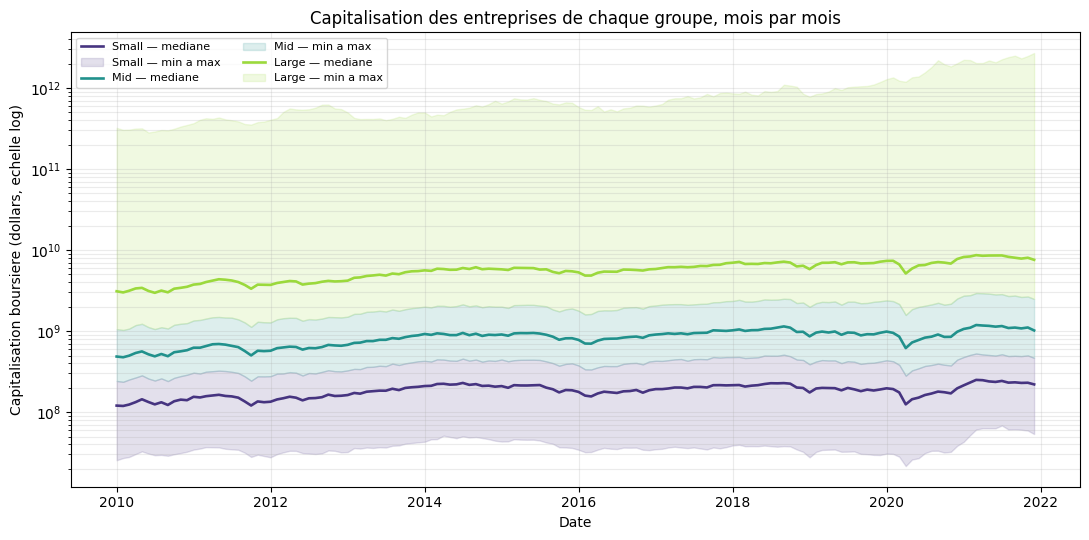

Graphique sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\analyse_taille_evolution_capitalisations.png


In [6]:
bornes_dt = bornes.copy()
bornes_dt['date'] = pd.to_datetime(bornes_dt['annee_mois'], format='%Y%m')

fig, ax = plt.subplots(figsize=(11, 5.5))
couleurs = plt.cm.viridis(np.linspace(0.15, 0.85, len(NOMS_GROUPES)))

for couleur, nom in zip(couleurs, NOMS_GROUPES):
    b = bornes_dt[bornes_dt['groupe'] == nom].sort_values('date')
    ax.plot(b['date'], b['capi_mediane'], label=f"{nom} — mediane", color=couleur, linewidth=1.9)
    ax.fill_between(b['date'], b['capi_min'], b['capi_max'], color=couleur, alpha=0.15,
                    label=f"{nom} — min a max")

ax.set_yscale('log')
ax.set_xlabel("Date")
ax.set_ylabel("Capitalisation boursiere (dollars, echelle log)")
ax.set_title("Capitalisation des entreprises de chaque groupe, mois par mois")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.25, which='both')
plt.tight_layout()
plt.savefig(config.FICHIER_TAILLE_SEUILS_PNG, dpi=150)
plt.show()
print("Graphique sauvegarde :", config.FICHIER_TAILLE_SEUILS_PNG)

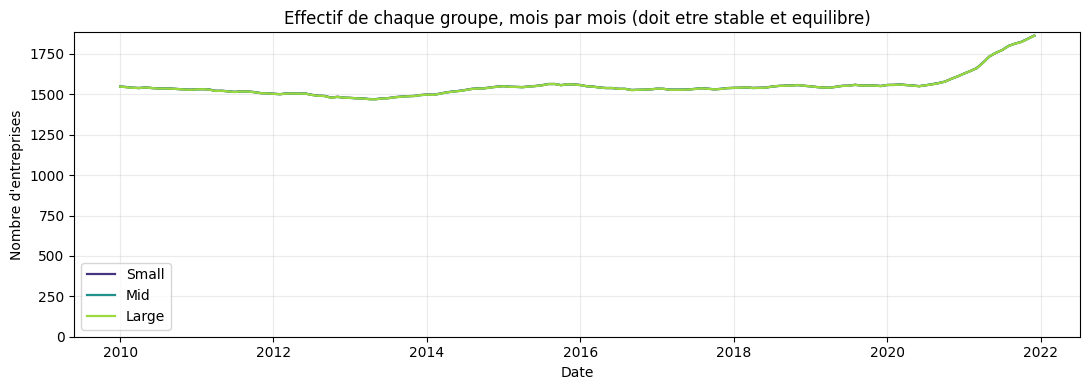

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
for couleur, nom in zip(couleurs, NOMS_GROUPES):
    b = bornes_dt[bornes_dt['groupe'] == nom].sort_values('date')
    ax.plot(b['date'], b['n_entreprises'], label=nom, color=couleur, linewidth=1.6)

ax.set_xlabel("Date")
ax.set_ylabel("Nombre d'entreprises")
ax.set_title("Effectif de chaque groupe, mois par mois (doit etre stable et equilibre)")
ax.legend()
ax.grid(alpha=0.25)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

---
## 3. `R²_oos` par modèle et par groupe

⚠️ **Rappel de l'avertissement n° 2** : ce tableau se lit **colonne par colonne** (quel modèle
est le meilleur *à l'intérieur* d'un groupe donné), **jamais ligne par ligne**. Comparer le
`R²_oos` du groupe « Small » à celui du groupe « Large » n'a pas de sens : leurs dénominateurs
$\sum y_i^2$ diffèrent, puisque les petites capitalisations sont plus volatiles. La comparaison
entre groupes se fait en section 4 (rank-IC).

In [8]:
performance = rap.table('performance')
performance['groupe'] = pd.Categorical(performance['groupe'], categories=ORDRE_GROUPES, ordered=True)

tableau_r2 = performance.pivot(index='modele', columns='groupe', values='r2_oos')
tableau_r2 = tableau_r2.reindex(columns=ORDRE_GROUPES)

print("R2_oos par modele (lignes) et par groupe (colonnes) :")
print("⚠️ A lire COLONNE par COLONNE uniquement -- voir l'avertissement 2 en tete de notebook.")
tableau_r2.round(5)

R2_oos par modele (lignes) et par groupe (colonnes) :
⚠️ A lire COLONNE par COLONNE uniquement -- voir l'avertissement 2 en tete de notebook.


groupe,Univers complet,Small,Mid,Large
modele,,,,
Elastic Net,0.00334,0.00152,0.00378,0.00806
LightGBM,-0.01061,-0.00939,-0.01051,-0.01454
Random Forest,0.00482,0.00301,0.00463,0.01070
Regression lineaire,-0.24320,-0.16447,-0.24661,-0.47612


---
## 4. Rank-IC — la mesure à privilégier pour comparer les groupes

Le **rank-IC** (*Information Coefficient* de rang) est la corrélation de Spearman, calculée
**mois par mois**, entre le **classement prédit** des titres et leur **classement réalisé** :

- il ne dépend que de l'**ordre** des titres, donc il est **invariant à l'échelle des
  rendements** — c'est précisément ce qui manque au `R²_oos` pour comparer deux sous-univers ;
- il correspond directement à ce qu'on demande au modèle dans une stratégie long-short : bien
  **classer**, pas prédire le niveau exact du rendement ;
- ordre de grandeur usuel en *asset pricing* pour un signal mensuel utile : **0,01 à 0,05**.

Trois colonnes complètent la moyenne :
- **`ic_t_stat`** : le rank-IC moyen est-il significativement différent de zéro ? (|t| > 2)
- **`ic_ir`** : régularité du signal (moyenne / écart-type, annualisée) — un IC modeste mais
  régulier vaut mieux qu'un IC élevé porté par quelques mois
- **`pct_mois_ic_positif`** : proportion de mois où le classement va dans le bon sens

In [9]:
tableau_ic = performance.pivot(index='modele', columns='groupe', values='ic_moyen').reindex(columns=ORDRE_GROUPES)
tableau_ic_t = performance.pivot(index='modele', columns='groupe', values='ic_t_stat').reindex(columns=ORDRE_GROUPES)
tableau_ic_ir = performance.pivot(index='modele', columns='groupe', values='ic_ir').reindex(columns=ORDRE_GROUPES)
tableau_ic_pos = performance.pivot(index='modele', columns='groupe', values='pct_mois_ic_positif').reindex(columns=ORDRE_GROUPES)

print("Rank-IC MOYEN (comparable entre groupes) :")
display(tableau_ic.round(4))
print("\nt-stat du rank-IC moyen (|t| > 2 = signal significatif) :")
display(tableau_ic_t.round(2))
print("\nInformation Ratio du signal (regularite, annualise) :")
display(tableau_ic_ir.round(2))
print("\n% de mois ou le classement va dans le bon sens :")
display((tableau_ic_pos * 100).round(1))

Rank-IC MOYEN (comparable entre groupes) :


groupe,Univers complet,Small,Mid,Large
modele,,,,
Elastic Net,-0.0104,0.0187,-0.0212,-0.0336
LightGBM,0.0042,0.0056,0.0001,-0.0011
Random Forest,0.0477,0.0625,0.0358,0.0227
Regression lineaire,0.0301,0.0498,0.0282,0.0165



t-stat du rank-IC moyen (|t| > 2 = signal significatif) :


groupe,Univers complet,Small,Mid,Large
modele,,,,
Elastic Net,-0.25,0.40,-0.55,-0.75
LightGBM,0.18,0.21,0.00,-0.06
Random Forest,5.31,7.18,3.86,2.30
Regression lineaire,4.18,6.09,3.67,2.01



Information Ratio du signal (regularite, annualise) :


groupe,Univers complet,Small,Mid,Large
modele,,,,
Elastic Net,-0.25,0.40,-0.55,-0.75
LightGBM,0.11,0.13,0.00,-0.04
Random Forest,1.53,2.07,1.11,0.66
Regression lineaire,1.21,1.76,1.06,0.58



% de mois ou le classement va dans le bon sens :


groupe,Univers complet,Small,Mid,Large
modele,,,,
Elastic Net,41.7,50.0,25.0,41.7
LightGBM,58.8,58.8,50.0,52.9
Random Forest,63.2,72.2,61.8,58.3
Regression lineaire,62.5,70.1,59.0,59.0


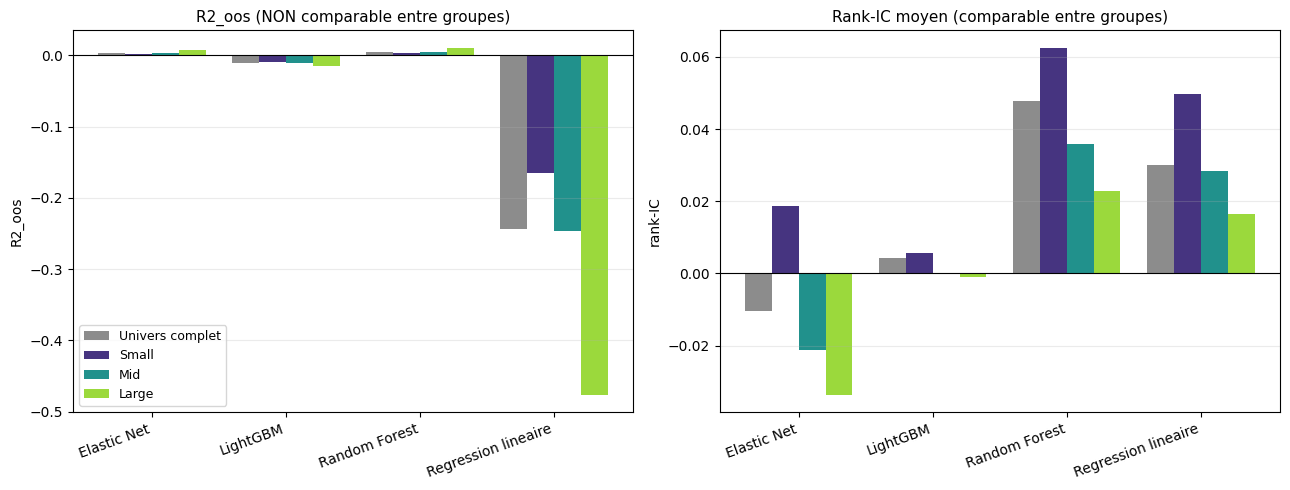

Graphique sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\analyse_taille_r2_et_ic.png


In [10]:
# Les deux mesures cote a cote : a gauche celle qu'on ne peut PAS comparer entre groupes,
# a droite celle qu'on PEUT comparer. Le contraste entre les deux panneaux est souvent
# le resultat le plus parlant de tout ce notebook.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
largeur = 0.8 / len(ORDRE_GROUPES)
positions = np.arange(len(tableau_ic.index))
couleurs_groupes = ['0.55'] + list(plt.cm.viridis(np.linspace(0.15, 0.85, len(NOMS_GROUPES))))

for ax, tableau, titre, ylabel in [
    (axes[0], tableau_r2, "R2_oos (NON comparable entre groupes)", "R2_oos"),
    (axes[1], tableau_ic, "Rank-IC moyen (comparable entre groupes)", "rank-IC"),
]:
    for i, (groupe, couleur) in enumerate(zip(ORDRE_GROUPES, couleurs_groupes)):
        if groupe not in tableau.columns:
            continue
        ax.bar(positions + i * largeur, tableau[groupe].values, width=largeur,
               label=groupe, color=couleur)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(positions + largeur * (len(ORDRE_GROUPES) - 1) / 2)
    ax.set_xticklabels(tableau.index, rotation=20, ha='right')
    ax.set_title(titre, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25, axis='y')

axes[0].legend(fontsize=9)
plt.tight_layout()
plt.savefig(config.FICHIER_TAILLE_R2_PNG, dpi=150)
plt.show()
print("Graphique sauvegarde :", config.FICHIER_TAILLE_R2_PNG)

---
## 5. Rendement moyen par décile, groupe par groupe

⚠️ **Point de méthode** : les déciles sont **recalculés à l'intérieur de chaque groupe**, mois
par mois. Réutiliser les déciles de l'univers complet n'aurait aucun sens — le décile 10 de
l'univers complet peut ne contenir presque aucune petite capitalisation, et le « portefeuille
small cap » serait alors vide ou minuscule certains mois.

Un signal de bonne qualité produit des rendements **croissants** du décile 1 au décile 10. Un
profil plat signale que le classement du modèle n'apporte rien **dans ce groupe**.

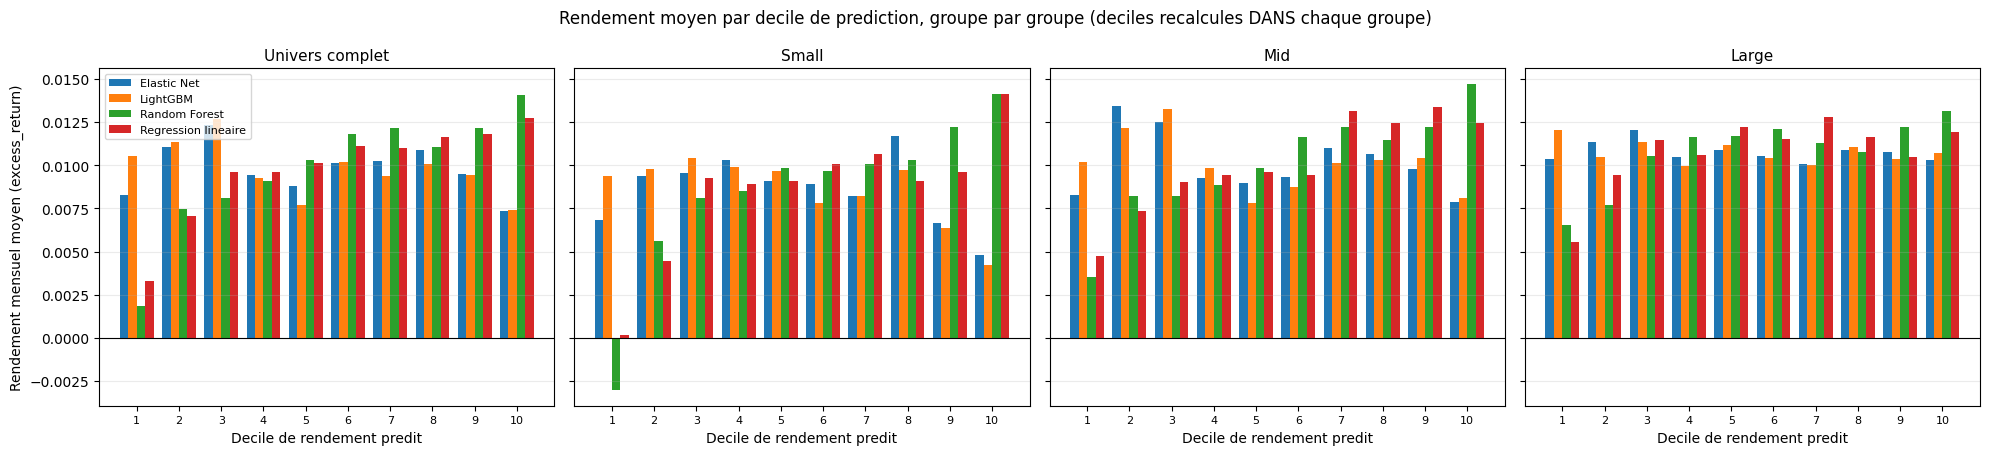

Graphique sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\analyse_taille_rendement_par_decile.png


In [11]:
rendement_par_decile = rap.table('rendement_par_decile')
nb_deciles = rap.valeur('nb_deciles')

n_groupes = len(ORDRE_GROUPES)
fig, axes = plt.subplots(1, n_groupes, figsize=(5 * n_groupes, 4.6), sharey=True)
axes = np.atleast_1d(axes)

largeur = 0.8 / len(MODELES)
positions = np.arange(nb_deciles)

for ax, groupe in zip(axes, ORDRE_GROUPES):
    sous = rendement_par_decile[rendement_par_decile['groupe'] == groupe]
    for i, modele in enumerate(MODELES):
        valeurs = (sous[sous['modele'] == modele]
                   .sort_values('decile')['rendement_moyen'].values)
        if len(valeurs) == 0:
            continue
        ax.bar(positions + i * largeur, valeurs, width=largeur, label=modele)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(positions + largeur * (len(MODELES) - 1) / 2)
    ax.set_xticklabels(range(1, nb_deciles + 1), fontsize=8)
    ax.set_xlabel("Decile de rendement predit")
    ax.set_title(groupe, fontsize=11)
    ax.grid(alpha=0.25, axis='y')

axes[0].set_ylabel(f"Rendement mensuel moyen ({config.CIBLE})")
axes[0].legend(fontsize=8)
fig.suptitle("Rendement moyen par decile de prediction, groupe par groupe "
             "(deciles recalcules DANS chaque groupe)", fontsize=12)
plt.tight_layout()
plt.savefig(config.FICHIER_TAILLE_DECILES_PNG, dpi=150)
plt.show()
print("Graphique sauvegarde :", config.FICHIER_TAILLE_DECILES_PNG)

---
## 6. Portefeuilles long-short construits à l'intérieur de chaque groupe

Même construction qu'au notebook 08 (achat du décile 10, vente à découvert du décile 1,
équipondéré, rebalancement mensuel), mais **à l'intérieur de chaque groupe** : c'est un
portefeuille qu'on pourrait réellement construire en se restreignant à ce segment de marché.

ℹ️ **Contrôle de cohérence** : la ligne « *Univers complet* » doit reproduire **exactement**
les chiffres du notebook 08 (mêmes prédictions, mêmes déciles, mêmes formules — la logique
est désormais partagée via `portefeuilles.py`). Si ce n'est pas le cas, c'est que le panel a
été régénéré avec d'autres filtres depuis le dernier entraînement des modèles.

In [12]:
colonnes_perf = ['groupe', 'n_titres_mois', 'r2_oos', 'ic_moyen', 'ic_t_stat',
                 'spread_decile_haut_bas', 'rendement_annualise', 'volatilite_annualisee',
                 'sharpe_ratio', 'sortino_ratio', 'max_drawdown', 't_stat', 'p_value',
                 'pct_mois_positifs', 'n_mois']

for modele in MODELES:
    sous = (performance[performance['modele'] == modele]
            .sort_values('groupe')[colonnes_perf]
            .set_index('groupe'))
    print("=" * 100)
    print(f"MODELE : {modele}")
    print("=" * 100)
    display(sous.round(4))

MODELE : Elastic Net


,n_titres_mois,r2_oos,ic_moyen,ic_t_stat,spread_decile_haut_bas,rendement_annualise,volatilite_annualisee,sharpe_ratio,sortino_ratio,max_drawdown,t_stat,p_value,pct_mois_positifs,n_mois
groupe,,,,,,,,,,,,,,
Univers complet,669550,0.0033,-0.0104,-0.2512,-0.0009,-0.0108,0.0639,-0.1693,-0.2607,-0.2595,-0.5866,0.5584,0.4583,144
Small,223240,0.0015,0.0187,0.4039,-0.0020,-0.0240,0.1020,-0.2355,-0.3284,-0.4398,-0.8157,0.4160,0.4236,144
Mid,223175,0.0038,-0.0212,-0.5549,-0.0004,-0.0048,0.0687,-0.0698,-0.1067,-0.2280,-0.2418,0.8093,0.4792,144
Large,223135,0.0081,-0.0336,-0.7545,-0.0001,-0.0010,0.0564,-0.0183,-0.0258,-0.1358,-0.0633,0.9496,0.5278,144


MODELE : LightGBM


,n_titres_mois,r2_oos,ic_moyen,ic_t_stat,spread_decile_haut_bas,rendement_annualise,volatilite_annualisee,sharpe_ratio,sortino_ratio,max_drawdown,t_stat,p_value,pct_mois_positifs,n_mois
groupe,,,,,,,,,,,,,,
Univers complet,669550,-0.0106,0.0042,0.1841,-0.0031,-0.0373,0.0955,-0.3912,-0.5149,-0.3908,-1.3550,0.1775,0.4375,144
Small,223240,-0.0094,0.0056,0.2109,-0.0051,-0.0616,0.1244,-0.4954,-0.6015,-0.5644,-1.7160,0.0883,0.4375,144
Mid,223175,-0.0105,0.0001,0.0023,-0.0021,-0.0251,0.0960,-0.2620,-0.3545,-0.3518,-0.9076,0.3656,0.4722,144
Large,223135,-0.0145,-0.0011,-0.0636,-0.0013,-0.0157,0.0787,-0.1996,-0.2476,-0.3312,-0.6915,0.4904,0.5347,144


MODELE : Random Forest


,n_titres_mois,r2_oos,ic_moyen,ic_t_stat,spread_decile_haut_bas,rendement_annualise,volatilite_annualisee,sharpe_ratio,sortino_ratio,max_drawdown,t_stat,p_value,pct_mois_positifs,n_mois
groupe,,,,,,,,,,,,,,
Univers complet,669550,0.0048,0.0477,5.3073,0.0122,0.1468,0.1600,0.9175,1.4999,-0.3529,3.1783,0.0018,0.6458,144
Small,223240,0.0030,0.0625,7.1788,0.0172,0.2063,0.1872,1.1017,1.8446,-0.3103,3.8163,0.0002,0.6528,144
Mid,223175,0.0046,0.0358,3.8606,0.0112,0.1343,0.1663,0.8080,1.3086,-0.4432,2.7990,0.0058,0.6042,144
Large,223135,0.0107,0.0227,2.3029,0.0066,0.0793,0.1343,0.5908,0.9388,-0.3430,2.0465,0.0425,0.5694,144


MODELE : Regression lineaire


,n_titres_mois,r2_oos,ic_moyen,ic_t_stat,spread_decile_haut_bas,rendement_annualise,volatilite_annualisee,sharpe_ratio,sortino_ratio,max_drawdown,t_stat,p_value,pct_mois_positifs,n_mois
groupe,,,,,,,,,,,,,,
Univers complet,669550,-0.2432,0.0301,4.1849,0.0095,0.1135,0.1076,1.0553,1.8536,-0.1148,3.6558,0.0004,0.6319,144
Small,223240,-0.1645,0.0498,6.0865,0.0139,0.1673,0.1503,1.1130,1.8886,-0.1658,3.8556,0.0002,0.6944,144
Mid,223175,-0.2466,0.0282,3.6662,0.0077,0.0921,0.1236,0.7456,1.3098,-0.2466,2.5829,0.0108,0.5625,144
Large,223135,-0.4761,0.0165,2.0095,0.0064,0.0764,0.1022,0.7477,1.2479,-0.1984,2.5900,0.0106,0.5903,144


In [13]:
# Le tableau de synthese le plus utile : le Sharpe du portefeuille long-short de chaque
# (modele x groupe), c'est-a-dire la valeur ECONOMIQUE du signal dans chaque segment.
tableau_sharpe = performance.pivot(index='modele', columns='groupe', values='sharpe_ratio').reindex(columns=ORDRE_GROUPES)
tableau_tstat = performance.pivot(index='modele', columns='groupe', values='t_stat').reindex(columns=ORDRE_GROUPES)

print("Ratio de Sharpe du portefeuille long-short, par modele et par groupe :")
display(tableau_sharpe.round(3))
print("\nt-stat du rendement moyen du long-short (|t| > 2 = significatif) :")
display(tableau_tstat.round(2))

Ratio de Sharpe du portefeuille long-short, par modele et par groupe :


groupe,Univers complet,Small,Mid,Large
modele,,,,
Elastic Net,-0.169,-0.235,-0.070,-0.018
LightGBM,-0.391,-0.495,-0.262,-0.200
Random Forest,0.917,1.102,0.808,0.591
Regression lineaire,1.055,1.113,0.746,0.748



t-stat du rendement moyen du long-short (|t| > 2 = significatif) :


groupe,Univers complet,Small,Mid,Large
modele,,,,
Elastic Net,-0.59,-0.82,-0.24,-0.06
LightGBM,-1.36,-1.72,-0.91,-0.69
Random Forest,3.18,3.82,2.80,2.05
Regression lineaire,3.66,3.86,2.58,2.59


---
## 7. Richesse cumulée, groupe par groupe

Richesse cumulée (base 1) du portefeuille long-short de chaque modèle, **dans chaque groupe**.
Un panneau par groupe, échelles partagées pour que la comparaison visuelle soit honnête.

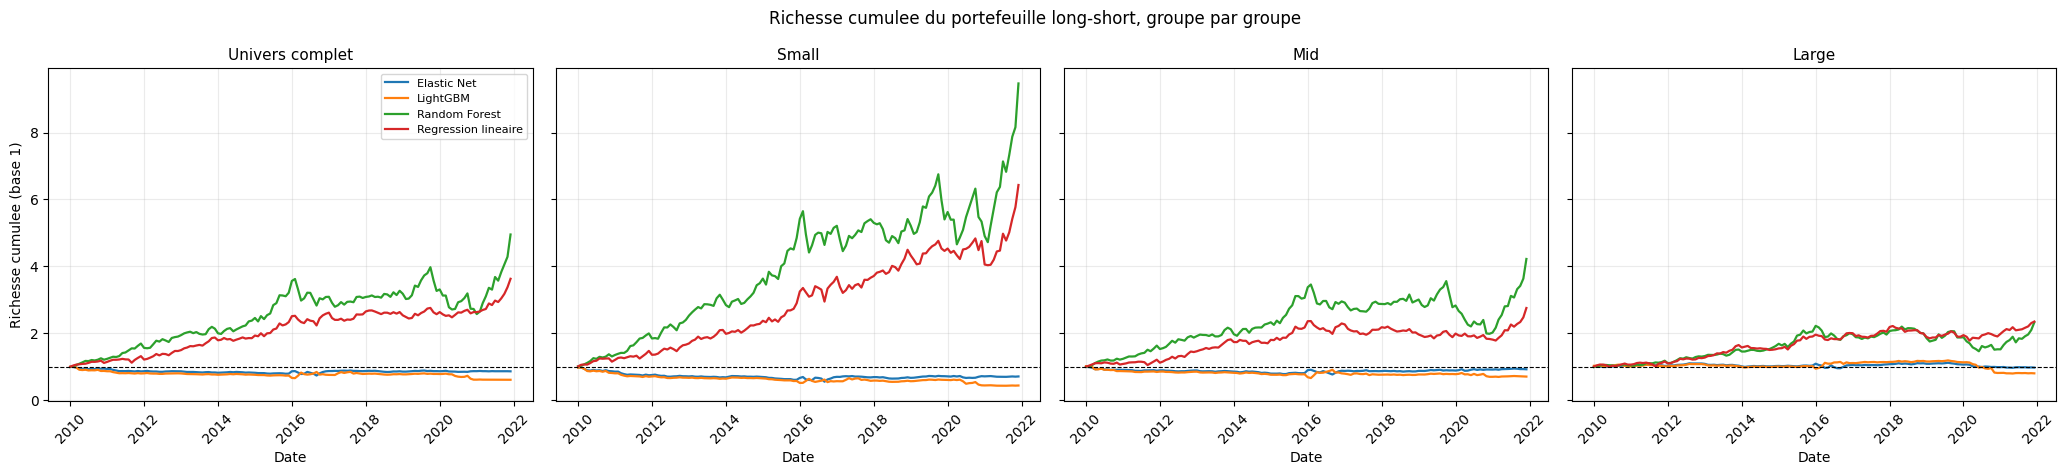

Graphique sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\analyse_taille_richesse_cumulee.png


In [14]:
rendements_ls = rap.table('rendements_long_short')
rendements_ls['date'] = pd.to_datetime(rendements_ls['annee_mois'], format='%Y%m')

fig, axes = plt.subplots(1, n_groupes, figsize=(5.2 * n_groupes, 4.8), sharey=True)
axes = np.atleast_1d(axes)

for ax, groupe in zip(axes, ORDRE_GROUPES):
    sous = rendements_ls[rendements_ls['groupe'] == groupe]
    for modele in MODELES:
        serie = sous[sous['modele'] == modele].sort_values('date')
        if len(serie) == 0:
            continue
        richesse = (1 + serie['rendement_long_short']).cumprod()
        ax.plot(serie['date'], richesse.values, label=modele, linewidth=1.6)
    ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(groupe, fontsize=11)
    ax.set_xlabel("Date")
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel("Richesse cumulee (base 1)")
axes[0].legend(fontsize=8)
fig.suptitle("Richesse cumulee du portefeuille long-short, groupe par groupe", fontsize=12)
plt.tight_layout()
plt.savefig(config.FICHIER_TAILLE_CUMULATIF_PNG, dpi=150)
plt.show()
print("Graphique sauvegarde :", config.FICHIER_TAILLE_CUMULATIF_PNG)

---
## 8. Synthèse

La cellule ci-dessous résume, pour chaque modèle, dans quel groupe le signal est le plus fort
— en s'appuyant sur le **rank-IC** (comparable entre groupes) et sur le **Sharpe** du
long-short (valeur économique), **jamais** sur le `R²_oos`.

In [15]:
print("Ou chaque modele fonctionne-t-il le mieux ? (groupes uniquement, hors univers complet)")
print()
for modele in MODELES:
    sous = performance[(performance['modele'] == modele)
                       & (performance['groupe'].isin(NOMS_GROUPES))]
    if len(sous) == 0:
        continue
    meilleur_ic = sous.loc[sous['ic_moyen'].idxmax()]
    meilleur_sharpe = sous.loc[sous['sharpe_ratio'].idxmax()]
    reference = performance[(performance['modele'] == modele)
                            & (performance['groupe'] == GROUPE_TOUS)].iloc[0]

    print(f"--- {modele} " + "-" * (60 - len(modele)))
    print(f"  Reference (univers complet) : rank-IC = {reference['ic_moyen']:+.4f} "
          f"(t = {reference['ic_t_stat']:+.2f}) | Sharpe = {reference['sharpe_ratio']:+.3f}")
    print(f"  Meilleur rank-IC : « {meilleur_ic['groupe']} » "
          f"({meilleur_ic['ic_moyen']:+.4f}, t = {meilleur_ic['ic_t_stat']:+.2f})")
    print(f"  Meilleur Sharpe  : « {meilleur_sharpe['groupe']} » "
          f"({meilleur_sharpe['sharpe_ratio']:+.3f}, t = {meilleur_sharpe['t_stat']:+.2f})")
    ecart = sous.set_index('groupe')['ic_moyen']
    print(f"  Rank-IC par groupe : "
          + " | ".join(f"{g} = {ecart[g]:+.4f}" for g in NOMS_GROUPES if g in ecart.index))
    print()

Ou chaque modele fonctionne-t-il le mieux ? (groupes uniquement, hors univers complet)

--- Elastic Net -------------------------------------------------
  Reference (univers complet) : rank-IC = -0.0104 (t = -0.25) | Sharpe = -0.169
  Meilleur rank-IC : « Small » (+0.0187, t = +0.40)
  Meilleur Sharpe  : « Large » (-0.018, t = -0.06)
  Rank-IC par groupe : Small = +0.0187 | Mid = -0.0212 | Large = -0.0336

--- LightGBM ----------------------------------------------------
  Reference (univers complet) : rank-IC = +0.0042 (t = +0.18) | Sharpe = -0.391
  Meilleur rank-IC : « Small » (+0.0056, t = +0.21)
  Meilleur Sharpe  : « Large » (-0.200, t = -0.69)
  Rank-IC par groupe : Small = +0.0056 | Mid = +0.0001 | Large = -0.0011

--- Random Forest -----------------------------------------------
  Reference (univers complet) : rank-IC = +0.0477 (t = +5.31) | Sharpe = +0.917
  Meilleur rank-IC : « Small » (+0.0625, t = +7.18)
  Meilleur Sharpe  : « Small » (+1.102, t = +3.82)
  Rank-IC par gro

**Résumé de ce notebook.** Les prédictions déjà sauvegardées par les étapes 04 à 07 ont été
ré-évaluées séparément sur chaque segment de capitalisation, sans aucun ré-entraînement et
sans modifier quoi que ce soit au pipeline principal (étapes 04 à 07 et notebooks 04 à 09
restent strictement inchangés).

**Ce qu'il faut retenir pour la rédaction :**
- la comparaison **entre groupes** se fait sur le **rank-IC** et le **Sharpe**, jamais sur le
  `R²_oos` (avertissement 2) ;
- la comparaison **entre modèles** se fait à l'intérieur d'un groupe donné, sur n'importe
  laquelle des mesures ;
- l'univers est **déjà filtré** en amont : parler de « titres de la moitié inférieure de
  capitalisation de l'univers investissable », pas de « small caps » (avertissement 1) ;
- le découpage est **mensuel**, les groupes ne sont donc pas des portefeuilles d'entreprises
  fixes (avertissement 3).

**Limites héritées du notebook 08**, qui valent ici aussi : portefeuilles équipondérés (pas
pondérés par la capitalisation), aucun coût de transaction ni turnover déduit — la
performance affichée est donc une **borne haute** de ce qui serait réellement atteignable,
et cette borne est d'autant plus optimiste que le groupe est petit, puisque les coûts de
transaction et l'impact de marché sont plus élevés sur les petites capitalisations. C'est un
point à mentionner explicitement si le groupe « Small » ressort comme le plus performant.

**Pour changer le découpage** : modifier `config.MODE_GROUPES_TAILLE` puis relancer
**uniquement** `python scripts/etape10_analyse_par_taille.py`. L'étape 03 ne stocke que la
capitalisation brute (`mvel1_brut`) ; les groupes en sont dérivés ici, à chaque exécution.
Ni ré-entraînement, ni reconstruction du panel, et aucune désynchronisation possible entre
un découpage figé dans le panel et celui de `config.py`.

Cinq découpages disponibles : `'mediane'`, `'terciles'`, `'quintiles'`, `'personnalise'`
(percentiles sur mesure) et `'dollars'` (seuils absolus en dollars, avec zone tampon
optionnelle — voir les avertissements de `config.py`).